This notebook aims at training the ML algorithms using structure-related decriptors

**Dataset C**: Calculated PDFs of CSD crystal structures

**Classes**: Nuclearity classes (1-9) + polymer class labeled as 10

In [1]:
import os
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np
from numpy import trapz
import sys
from pathlib import Path

# Add parent directory to path for config import
sys.path.insert(0, '../../')
from config import get_path, setup_workdir

Plot the distribution of nuclearities in the dataset C

Working directory: /workspace/home/pdf-nn-data/csd_structures/calculated_pdfs
Total CSD structures: 645
Nuclearity distribution: {'1': 70, '2': 166, '3': 6, '4': 99, '5': 7, '6': 22, '7': 14, '8': 17, '9': 30, '10': 214}


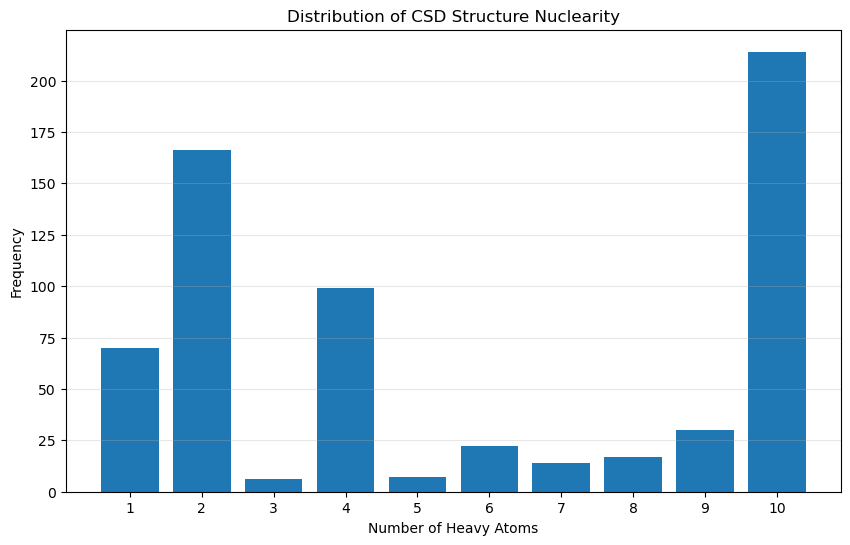

In [2]:
# Set working directory and paths using config
setup_workdir('csd_calculated_pdfs')
labels_path = get_path('labels') / 'csd_labels.txt'

def read_txt_file(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()
    return [int(line.strip()) for line in lines]

def count_occurrences(numbers):
    count_dict = {str(i): 0 for i in range(1, 11)}  # Include 10 for polymers
    for number in numbers:
        if 1 <= number <= 10:  # Include polymer class (10)
            count_dict[str(number)] += 1
    return count_dict

def plot_bar_chart(count_dict):
    numbers = list(count_dict.keys())
    counts = list(count_dict.values())

    plt.figure(figsize=(10, 6))
    plt.bar(numbers, counts)
    plt.xlabel('Number of Heavy Atoms')
    plt.ylabel('Frequency')
    plt.title('Distribution of CSD Structure Nuclearity')
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()

numbers = read_txt_file(labels_path)
count_dict = count_occurrences(numbers)
print(f"Total CSD structures: {len(numbers)}")
print(f"Nuclearity distribution: {count_dict}")
plot_bar_chart(count_dict)

Feature Extraction from PDF Files
- Peak areas and ratios
- Peak positions and heights
- Shell integrals (wider r-range compared to peak area descriptors)
- PDF moments descriptors

CSD PDF files directory: /workspace/home/pdf-nn-data/csd_structures/calculated_pdfs
Feature output directory: /workspace/home/pdf-nn-data/csd_structures/pdf_features
Found 645 CSD PDF files to process


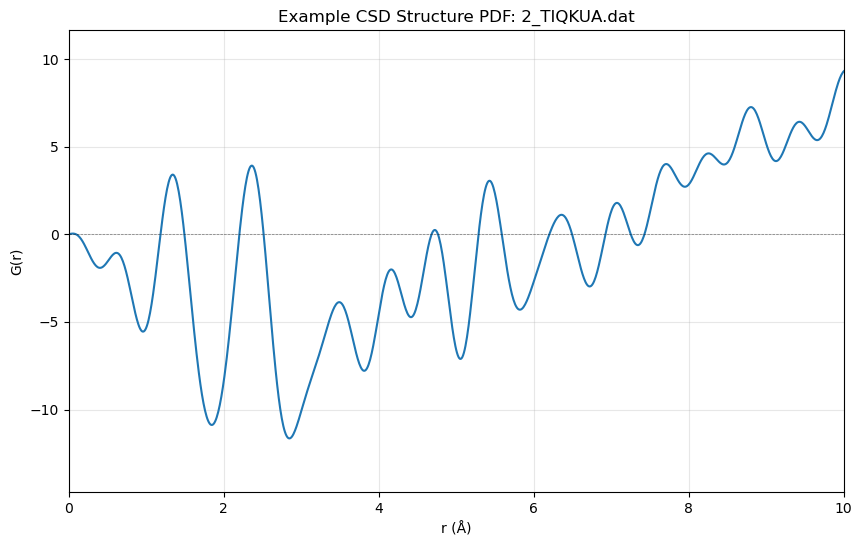

In [ ]:
# Setup directories
pdf_dir = get_path('csd_calculated_pdfs')
csd_features_dir = get_path('csd_structures') / 'pdf_features'
csd_features_dir.mkdir(parents=True, exist_ok=True)

print(f"CSD PDF files directory: {pdf_dir}")
print(f"Feature output directory: {csd_features_dir}")

files_pdf = list(pdf_dir.glob('*.dat'))
print(f"Found {len(files_pdf)} CSD PDF files to process")

# Plot example CSD PDF
if len(files_pdf) > 0:
    example_file = files_pdf[0]
    data = pd.read_csv(example_file, skiprows=1, delim_whitespace=True, index_col=False)
    data.columns = ['r', 'g']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(data.r, data.g, linewidth=1.5)
    ax.set_xlim(0, 10)
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('G(r)')
    ax.set_title(f'Example CSD Structure PDF: {example_file.name}')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.show()

In [ ]:
features_path = csd_features_dir / 'csd_pdf_features.txt'

print(f"Extracting features from {len(files_pdf)} CSD PDF files...")

def extract_pdf_features(df):
    """Extract comprehensive PDF features for classification"""
    features = {}
    
    # Define peak regions
    peak1_mask = (df['r'] >= 2.0) & (df['r'] <= 3.0)
    peak2_mask = (df['r'] >= 3.5) & (df['r'] <= 4.2) 
    peak3_mask = (df['r'] >= 6.0) & (df['r'] <= 7.0)
    
    peak1 = df.loc[peak1_mask]
    peak2 = df.loc[peak2_mask]
    peak3 = df.loc[peak3_mask]
    
    # Peak areas (integrals of G(r))
    area1 = trapz(peak1.g, peak1.r) if len(peak1) > 0 else 0
    area2 = trapz(peak2.g, peak2.r) if len(peak2) > 0 else 0
    area3 = trapz(peak3.g, peak3.r) if len(peak3) > 0 else 0
    
    features['area1'] = area1
    features['area2'] = area2  
    features['area3'] = area3
    
    # Peak intensity ratios
    features['ratio_21'] = area2/area1 if area1 > 0 else 0
    features['ratio_23'] = area2/area3 if area3 > 0 else 0
    features['ratio_31'] = area3/area1 if area1 > 0 else 0
    
    # Peak positions (r-values at maximum intensity)
    features['peak1_pos'] = peak1.loc[peak1.g.idxmax(), 'r'] if len(peak1) > 0 and peak1.g.max() > 0 else 2.5
    features['peak2_pos'] = peak2.loc[peak2.g.idxmax(), 'r'] if len(peak2) > 0 and peak2.g.max() > 0 else 3.85
    features['peak3_pos'] = peak3.loc[peak3.g.idxmax(), 'r'] if len(peak3) > 0 and peak3.g.max() > 0 else 6.5
    
    # Peak heights (maximum intensities)
    features['peak1_height'] = peak1.g.max() if len(peak1) > 0 else 0
    features['peak2_height'] = peak2.g.max() if len(peak2) > 0 else 0
    features['peak3_height'] = peak3.g.max() if len(peak3) > 0 else 0
    
    # Peak height ratios
    features['height_21'] = features['peak2_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    features['height_31'] = features['peak3_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    
    # Coordination shell integrals (broader regions)
    shell1_mask = (df['r'] >= 1.5) & (df['r'] <= 3.5)
    shell2_mask = (df['r'] >= 3.0) & (df['r'] <= 5.0)
    shell3_mask = (df['r'] >= 5.5) & (df['r'] <= 7.5)
    
    features['shell1'] = trapz(df.loc[shell1_mask, 'g'], df.loc[shell1_mask, 'r']) if shell1_mask.any() else 0
    features['shell2'] = trapz(df.loc[shell2_mask, 'g'], df.loc[shell2_mask, 'r']) if shell2_mask.any() else 0
    features['shell3'] = trapz(df.loc[shell3_mask, 'g'], df.loc[shell3_mask, 'r']) if shell3_mask.any() else 0
    
    # PDF moments and shape descriptors
    r_vals = df['r'].values
    g_vals = df['g'].values
    
    # For PDF, handle negative values by using positive part only
    g_pos = np.maximum(g_vals, 0)
    
    # First moment (weighted average r-position of positive peaks)
    if np.sum(g_pos) > 0:
        features['moment1'] = np.sum(r_vals * g_pos) / np.sum(g_pos)
        features['moment2'] = np.sum((r_vals - features['moment1'])**2 * g_pos) / np.sum(g_pos)
    else:
        features['moment1'] = 0
        features['moment2'] = 0
    
    # Total PDF integral (0-10 Å)
    total_mask = (df['r'] >= 0) & (df['r'] <= 10)
    features['total_integral'] = trapz(df.loc[total_mask, 'g'], df.loc[total_mask, 'r']) if total_mask.any() else 0
    
    return features

# Load CSD labels
csd_labels = read_txt_file(labels_path)
print(f"Loaded {len(csd_labels)} CSD labels")

# Create label lookup by filename index
label_lookup = {i: label for i, label in enumerate(csd_labels)}

# Extract features from all CSD PDF files
all_features = []
with open(features_path, 'w') as f:
    # Write header
    feature_names = ['nuclearity', 'area1', 'area2', 'area3', 'ratio_21', 'ratio_23', 'ratio_31',
                     'peak1_pos', 'peak2_pos', 'peak3_pos', 'peak1_height', 'peak2_height', 'peak3_height',
                     'height_21', 'height_31', 'shell1', 'shell2', 'shell3', 
                     'moment1', 'moment2', 'total_integral']
    f.write(' '.join(feature_names) + '\n')
    
    for i, file_path in enumerate(sorted(files_pdf)):
        try:
            # Load PDF data
            data = pd.read_csv(file_path, skiprows=1, delim_whitespace=True, index_col=False)
            data.columns = ['r', 'g']
            
            # Extract features
            features = extract_pdf_features(data)
            
            # Get nuclearity from label file (by index)
            if i < len(csd_labels):
                nuclearity = csd_labels[i]
            else:
                print(f"Warning: No label for file {i}: {file_path.name}")
                continue
            
            # Only include valid nuclearities (1-10, where 10 = polymer)
            if not (1 <= nuclearity <= 10):
                continue
            
            # Write to file
            feature_row = [nuclearity] + [features[name] for name in feature_names[1:]]
            f.write(' '.join(map(str, feature_row)) + '\n')
            all_features.append(feature_row)
            
        except Exception as e:
            print(f"Error processing {file_path.name}: {e}")
            continue
            
        if i % 100 == 0:
            print(f"Extracted features from {i} files...")

print(f"Feature extraction complete")
print(f"  Features saved to: {features_path}")
print(f"  Total samples with valid nuclearity: {len(all_features)}")
print(f"  Total features per sample: {len(feature_names)-1}")

Extracting features from 645 CSD PDF files...
Loaded 645 CSD labels
Extracted features from 0 files...
Extracted features from 100 files...
Extracted features from 200 files...
Extracted features from 300 files...
Extracted features from 400 files...
Extracted features from 500 files...
Extracted features from 600 files...
Feature extraction complete
  Features saved to: /workspace/home/pdf-nn-data/csd_structures/pdf_features/csd_pdf_features.txt
  Total samples with valid nuclearity: 645
  Total features per sample: 20


## Data Visualization

Visualize CSD PDF features and compare with synthetic cluster data.

Loaded 645 CSD samples with 20 features


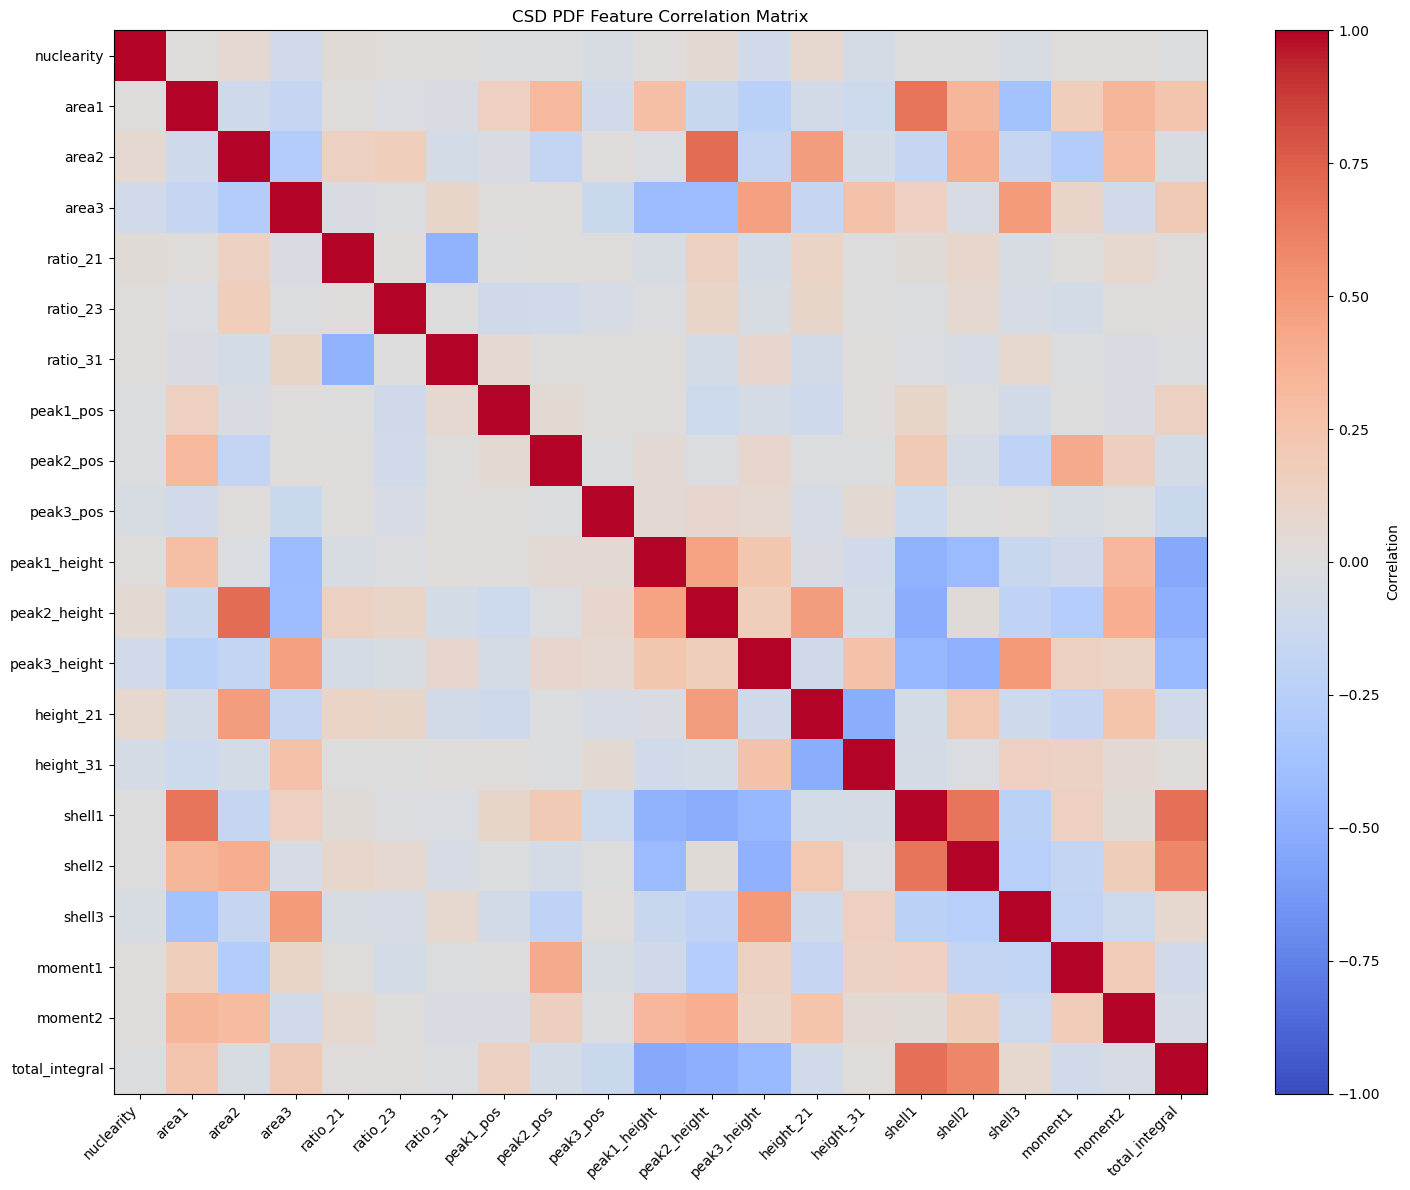

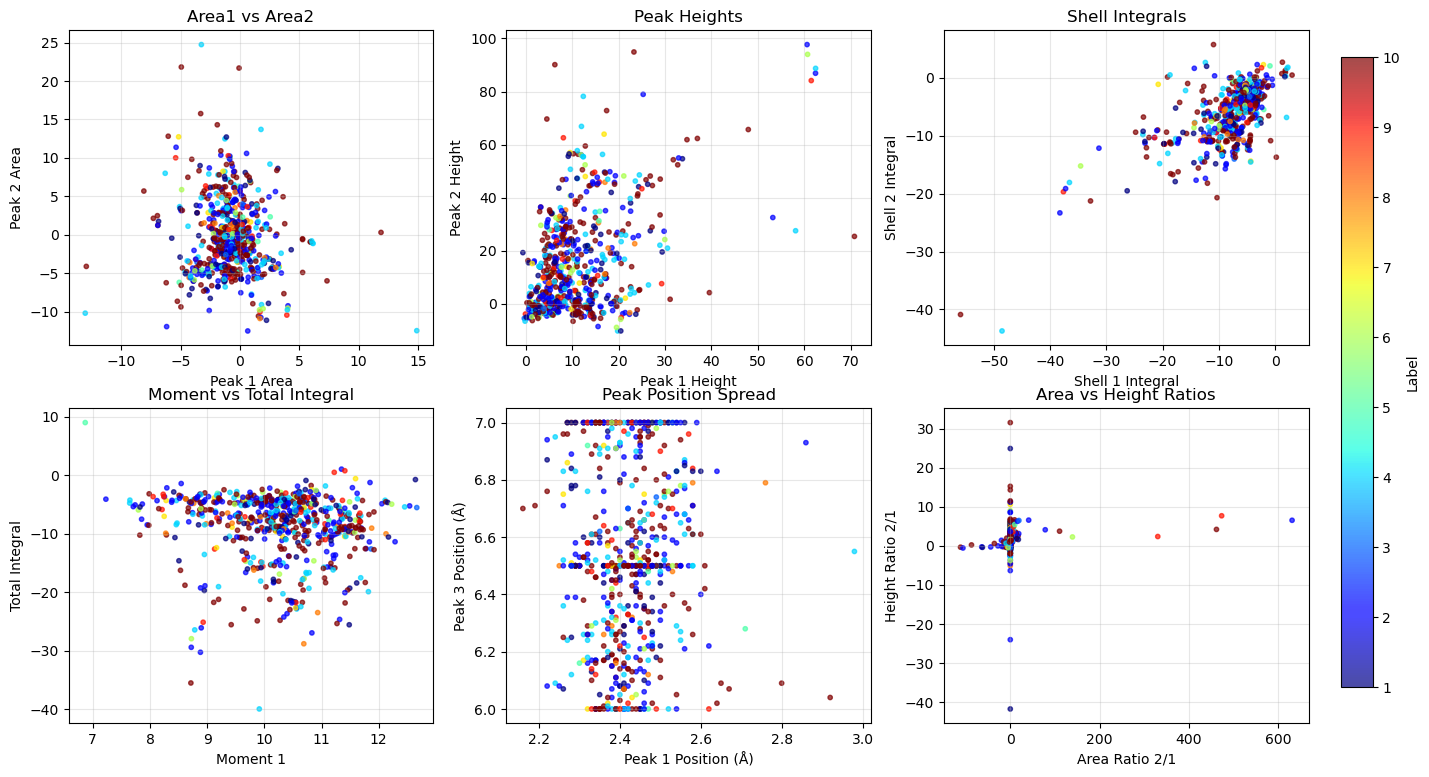


CSD Feature statistics:
       nuclearity    area1    area2    area3  ratio_21  ratio_23  ratio_31  \
count     645.000  645.000  645.000  645.000   645.000   645.000   645.000   
mean        5.623   -0.779   -0.348   -1.082     2.551    -0.326    -2.274   
std         3.643    2.345    4.864    3.823    39.989    10.660    28.101   
min         1.000  -13.046  -12.510  -16.909  -111.467  -162.387  -545.573   
25%         2.000   -1.868   -3.869   -2.678     0.000     0.000     0.000   
50%         4.000   -0.792   -0.961   -1.199     0.000     0.000     0.000   
75%        10.000    0.301    2.577   -0.075     0.000     0.000     0.000   
max        10.000   14.912   24.736   20.073   631.276   166.810   307.876   

       peak1_pos  peak2_pos  peak3_pos  ...  peak2_height  peak3_height  \
count    645.000    645.000    645.000  ...       645.000       645.000   
mean       2.421      3.900      6.541  ...        15.213         8.652   
std        0.093      0.197      0.320  ...    

In [ ]:
# Load and visualize CSD PDF features
features_data = pd.read_csv(features_path, delim_whitespace=True, header=0, index_col=False)
print(f"Loaded {len(features_data)} CSD samples with {len(feature_names)-1} features")

# Visualize feature correlations
plt.figure(figsize=(15, 12))
correlation_matrix = features_data.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.yticks(range(len(feature_names)), feature_names)
plt.title('CSD PDF Feature Correlation Matrix')
plt.tight_layout()
plt.show()


# Additional scatter plots for clustering insight
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
scatter_kwargs = dict(c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)

axes[0, 0].scatter(features_data['area1'], features_data['area2'], **scatter_kwargs)
axes[0, 0].set_xlabel('Peak 1 Area')
axes[0, 0].set_ylabel('Peak 2 Area')
axes[0, 0].set_title('Area1 vs Area2')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(features_data['peak1_height'], features_data['peak2_height'], **scatter_kwargs)
axes[0, 1].set_xlabel('Peak 1 Height')
axes[0, 1].set_ylabel('Peak 2 Height')
axes[0, 1].set_title('Peak Heights')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(features_data['shell1'], features_data['shell2'], **scatter_kwargs)
axes[0, 2].set_xlabel('Shell 1 Integral')
axes[0, 2].set_ylabel('Shell 2 Integral')
axes[0, 2].set_title('Shell Integrals')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(features_data['moment1'], features_data['total_integral'], **scatter_kwargs)
axes[1, 0].set_xlabel('Moment 1')
axes[1, 0].set_ylabel('Total Integral')
axes[1, 0].set_title('Moment vs Total Integral')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(features_data['peak1_pos'], features_data['peak3_pos'], **scatter_kwargs)
axes[1, 1].set_xlabel('Peak 1 Position (Å)')
axes[1, 1].set_ylabel('Peak 3 Position (Å)')
axes[1, 1].set_title('Peak Position Spread')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(features_data['ratio_21'], features_data['height_21'], **scatter_kwargs)
axes[1, 2].set_xlabel('Area Ratio 2/1')
axes[1, 2].set_ylabel('Height Ratio 2/1')
axes[1, 2].set_title('Area vs Height Ratios')
axes[1, 2].grid(True, alpha=0.3)

fig.colorbar(axes[0, 0].collections[0], ax=axes, label='Label', shrink=1, cax=fig.add_axes([0.92, 0.15, 0.02, 0.7]))
plt.show()

# Display feature statistics
print("\nCSD Feature statistics:")
print(features_data.describe().round(3))

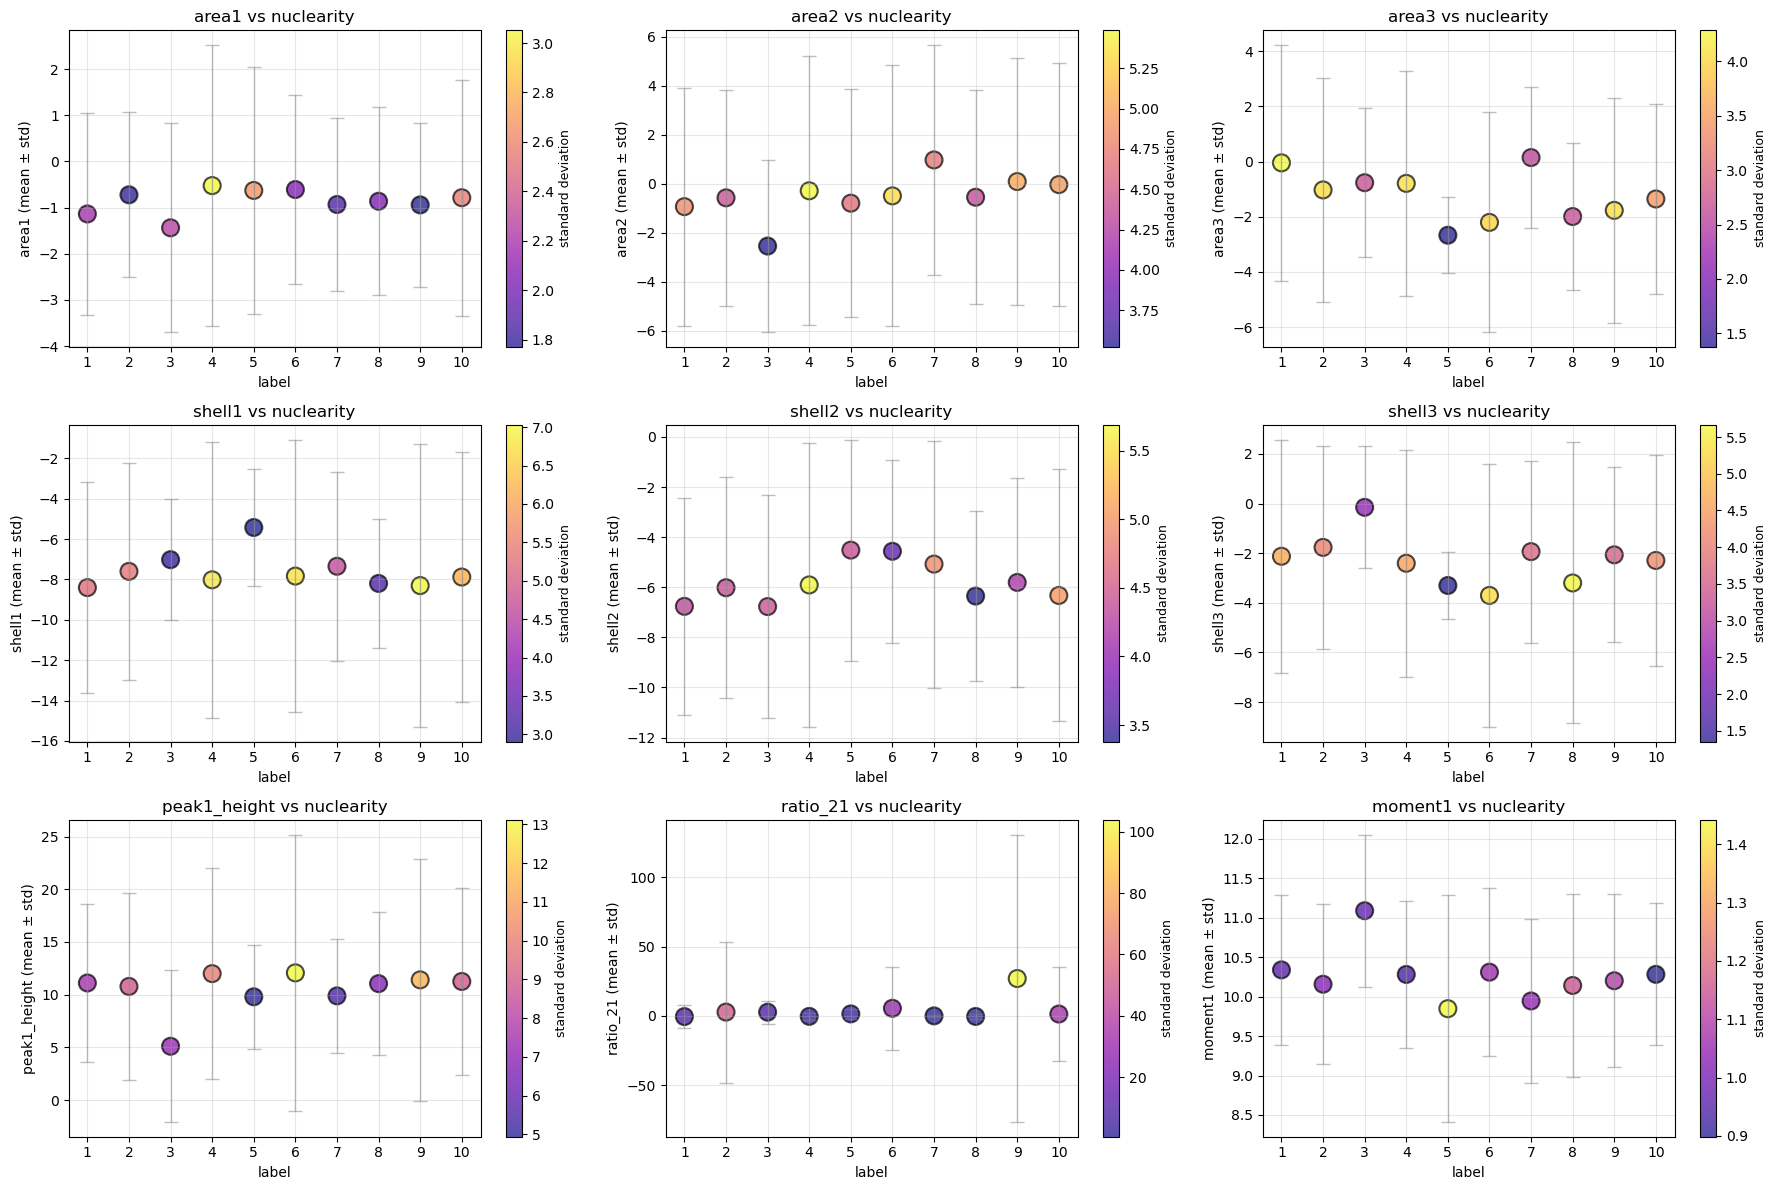

In [ ]:
# Feature vs nuclearity with dispersion analysis
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes_flat = axes.flatten()

# Calculate mean and std for each feature grouped by nuclearity
feature_dispersion = {}
nuclearity_values = sorted(features_data['nuclearity'].unique())

# Select key features for visualization
key_features = ['area1', 'area2', 'area3', 'shell1', 'shell2', 'shell3', 'peak1_height', 'ratio_21', 'moment1']

for idx, feature in enumerate(key_features):
    ax = axes_flat[idx]
    
    # Calculate mean and std for each nuclearity
    feature_means = []
    feature_stds = []
    
    for nuc in nuclearity_values:
        nuc_data = features_data[features_data['nuclearity'] == nuc][feature]
        feature_means.append(nuc_data.mean())
        feature_stds.append(nuc_data.std())
    
    # Create scatter plot: nuclearity vs feature value, colored by dispersion (std)
    scatter = ax.scatter(nuclearity_values, feature_means, 
                        c=feature_stds, cmap='plasma', s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add error bars showing std deviation
    ax.errorbar(nuclearity_values, feature_means, yerr=feature_stds, fmt='none', 
               ecolor='gray', alpha=0.5, capsize=5, linewidth=1)
    
    ax.set_xlabel('label')
    ax.set_ylabel(f'{feature} (mean ± std)')
    ax.set_title(f'{feature} vs nuclearity')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(nuclearity_values)
    
    # Add colorbar for this subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('standard deviation', fontsize=9)

# Hide any unused subplots
for j in range(len(key_features), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()


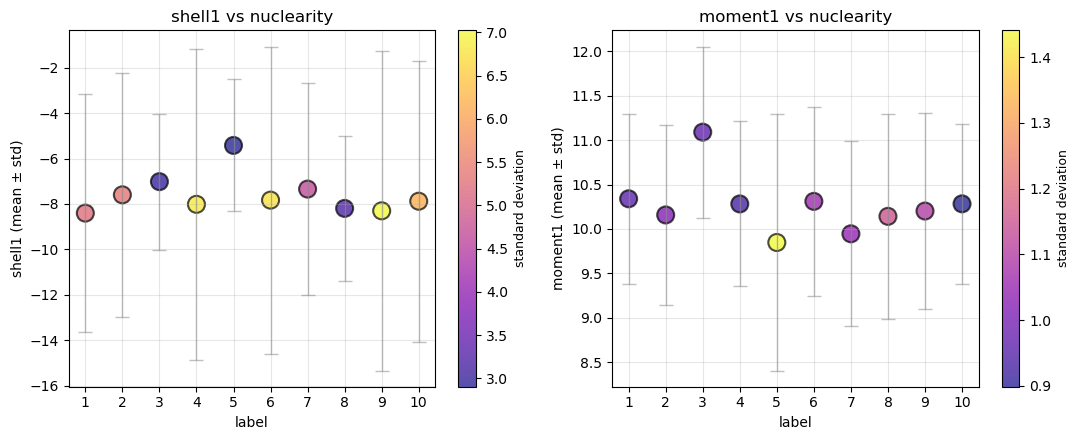

In [ ]:
# Feature vs nuclearity with dispersion analysis
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes_flat = axes.flatten()

# Calculate mean and std for each feature grouped by nuclearity
feature_dispersion = {}
nuclearity_values = sorted(features_data['nuclearity'].unique())

# Select key features for visualization
key_features = ['shell1', 'moment1']

for idx, feature in enumerate(key_features):
    ax = axes_flat[idx]
    
    # Calculate mean and std for each nuclearity
    feature_means = []
    feature_stds = []
    
    for nuc in nuclearity_values:
        nuc_data = features_data[features_data['nuclearity'] == nuc][feature]
        feature_means.append(nuc_data.mean())
        feature_stds.append(nuc_data.std())
    
    # Create scatter plot: nuclearity vs feature value, colored by dispersion (std)
    scatter = ax.scatter(nuclearity_values, feature_means, 
                        c=feature_stds, cmap='plasma', s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add error bars showing std deviation
    ax.errorbar(nuclearity_values, feature_means, yerr=feature_stds, fmt='none', 
               ecolor='gray', alpha=0.5, capsize=5, linewidth=1)
    
    ax.set_xlabel('label')
    ax.set_ylabel(f'{feature} (mean ± std)')
    ax.set_title(f'{feature} vs nuclearity')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(nuclearity_values)
    
    # Add colorbar for this subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('standard deviation', fontsize=9)

plt.tight_layout()
plt.show()


## Model Training: Gradient Boosting Classifier

Feature matrix shape: (645, 20)
Number of samples: 645
Unique classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Training samples: 516
Test samples: 129

Training Gradient Boosting Classifier on CSD PDF features...

Gradient Boosting Classification Results (CSD PDF features):
Accuracy: 0.225
F1-score (weighted): 0.210
F1-score (macro): 0.100

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.06      0.07      0.07        14
           2       0.22      0.27      0.24        33
           3       0.00      0.00      0.00         1
           4       0.20      0.10      0.13        20
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
           9       0.33      0.17      0.22         6
          10       0.30      0.37      0.33        43

    accuracy                        

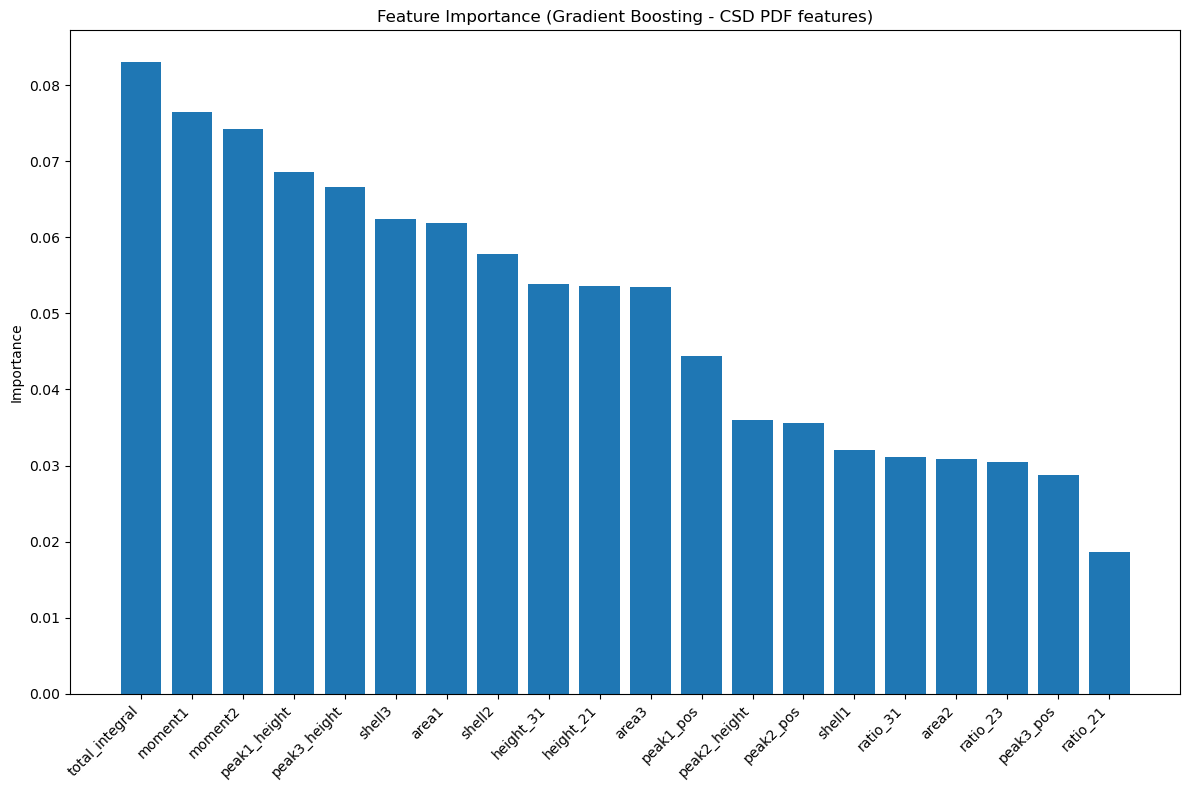


Top 10 most important CSD PDF features:
 1. total_integral      : 0.083
 2. moment1             : 0.077
 3. moment2             : 0.074
 4. peak1_height        : 0.069
 5. peak3_height        : 0.067
 6. shell3              : 0.062
 7. area1               : 0.062
 8. shell2              : 0.058
 9. height_31           : 0.054
10. height_21           : 0.054


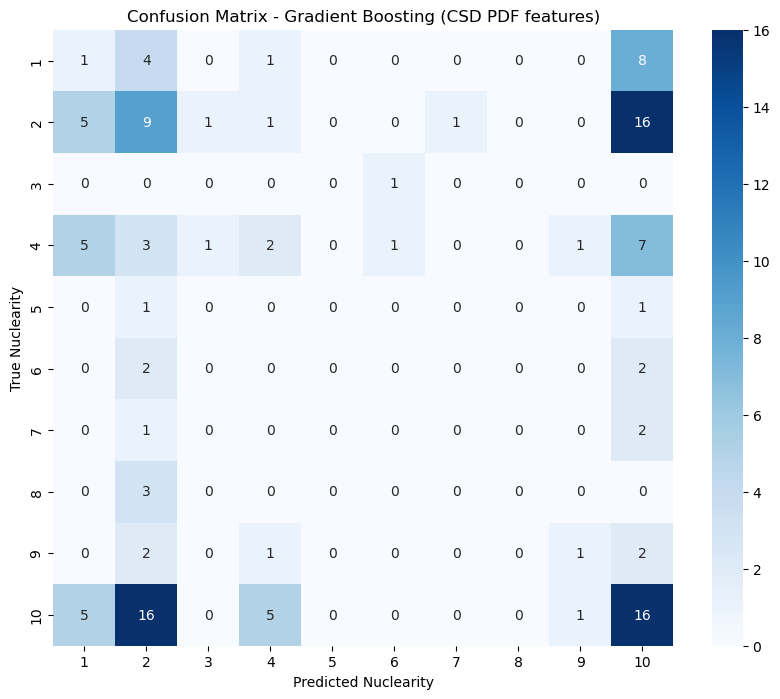

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for classification
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Number of samples: {len(y)}")
print(f"Unique classes: {sorted(np.unique(y))}")

# Check if we have enough samples for train/test split
if len(y) < 50:
    print(f"\nWARNING: Only {len(y)} samples available. Results may not be reliable.")
    print("Consider using cross-validation only or gathering more data.")

# Split the data into training and testing sets
test_size = 0.2 if len(y) >= 50 else 0.3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

print(f"\nTraining samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")

# Scale features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(
    n_estimators=300, 
    learning_rate=0.1, 
    max_depth=4,  # Reduced depth for smaller dataset
    random_state=42
)

print("\nTraining Gradient Boosting Classifier on CSD PDF features...")
gb_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gb_classifier.predict(X_test_scaled)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\n" + "="*70)
print("Gradient Boosting Classification Results (CSD PDF features):")
print("="*70)
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score (weighted): {f1_weighted:.3f}")
print(f"F1-score (macro): {f1_macro:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Cross-validation performance
cv_folds = min(5, len(np.unique(y_train)))  # Adjust CV folds based on smallest class
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb_classifier, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
print(f"\nCross-validation F1-scores ({cv_folds}-fold): {cv_scores}")
print(f"Mean CV F1-score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Feature importance
feature_importance = gb_classifier.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance)[::-1]
plt.bar(range(len(feature_importance)), feature_importance[indices])
plt.xticks(range(len(feature_importance)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Gradient Boosting - CSD PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 10 most important CSD PDF features:")
for i in range(min(10, len(feature_importance))):
    idx = indices[i]
    print(f"{i+1:2d}. {feature_names_clean[idx]:<20s}: {feature_importance[idx]:.3f}")

# Confusion matrix
plt.figure(figsize=(10, 8))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
plt.xlabel('Predicted Nuclearity')
plt.ylabel('True Nuclearity')
plt.title('Confusion Matrix - Gradient Boosting (CSD PDF features)')
plt.show()

## Model Training: Random Forest Classifier

Training Random Forest Classifier on CSD data...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.219

Random Forest Classification Results (CSD):
Accuracy: 0.302
F1-score (weighted): 0.198
F1-score (macro): 0.063

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        14
           2       0.21      0.15      0.18        33
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        20
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         6
          10       0.32      0.79      0.46        43

  

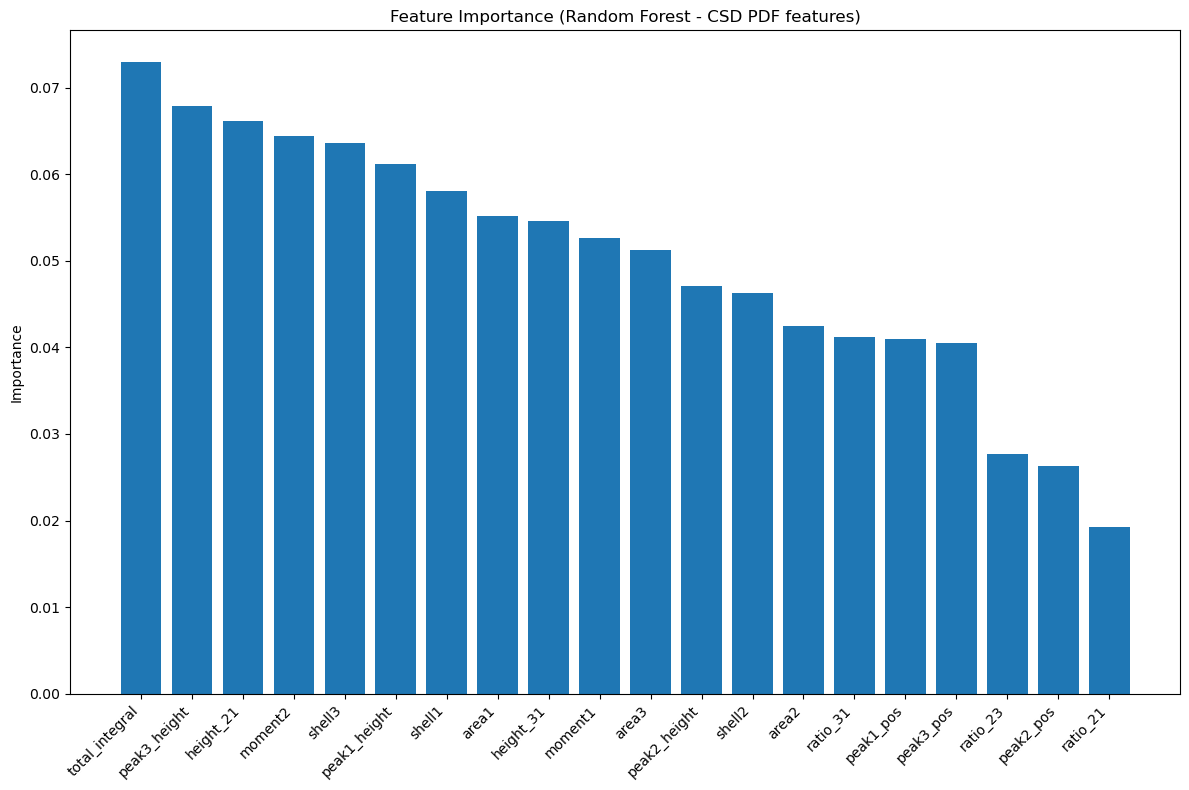


Top 10 most important features (Random Forest):
 1. total_integral      : 0.073
 2. peak3_height        : 0.068
 3. height_21           : 0.066
 4. moment2             : 0.064
 5. shell3              : 0.064
 6. peak1_height        : 0.061
 7. shell1              : 0.058
 8. area1               : 0.055
 9. height_31           : 0.055
10. moment1             : 0.053


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Training Random Forest Classifier on CSD data...")

# Simplified parameter grid for smaller dataset
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_classifier = RandomForestClassifier(random_state=42)

# Adjust CV folds for grid search
cv_folds = min(3, len(np.unique(y_train)))
grid_search = GridSearchCV(
    rf_classifier, 
    param_grid, 
    cv=cv_folds, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

y_pred_rf = best_rf.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

print(f"\nRandom Forest Classification Results (CSD):")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"F1-score (weighted): {f1_weighted_rf:.3f}")
print(f"F1-score (macro): {f1_macro_rf:.3f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Feature importance
feature_importance_rf = best_rf.feature_importances_

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance_rf)[::-1]
plt.bar(range(len(feature_importance_rf)), feature_importance_rf[indices])
plt.xticks(range(len(feature_importance_rf)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Random Forest - CSD PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 10 most important features (Random Forest):")
for i in range(min(10, len(feature_importance_rf))):
    idx = indices[i]
    print(f"{i+1:2d}. {feature_names_clean[idx]:<20s}: {feature_importance_rf[idx]:.3f}")

## Model Training: Bayesian Classification

In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import PolynomialFeatures

# Strategy 1: Feature Selection for Naive Bayes
print("1. Feature Selection for Naive Bayes")

k_features = min(10, X_train_scaled.shape[1])
selector = SelectKBest(score_func=mutual_info_classif, k=k_features)
X_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = np.array(feature_names_clean)[selector.get_support()]
print(f"Selected {k_features} features: {list(selected_features)}")

nb_improved = GaussianNB()
nb_improved.fit(X_selected, y_train)
y_pred_nb_improved = nb_improved.predict(X_test_selected)

accuracy_nb_improved = accuracy_score(y_test, y_pred_nb_improved)
f1_nb_improved = f1_score(y_test, y_pred_nb_improved, average='weighted', zero_division=0)

print(f"Improved Naive Bayes: {accuracy_nb_improved:.3f} accuracy, {f1_nb_improved:.3f} F1")

# Strategy 2: Tuned Logistic Regression
print("\n2. Hyperparameter Tuning for Logistic Regression")

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, multi_class='ovr'),
    param_grid_lr,
    cv=cv_folds,
    scoring='f1_weighted',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)
print(f"Best LogReg params: {lr_grid.best_params_}")

y_pred_lr_improved = lr_grid.predict(X_test_scaled)
accuracy_lr_improved = accuracy_score(y_test, y_pred_lr_improved)
f1_lr_improved = f1_score(y_test, y_pred_lr_improved, average='weighted', zero_division=0)

print(f"Improved Logistic Regression: {accuracy_lr_improved:.3f} accuracy, {f1_lr_improved:.3f} F1")

# Strategy 3: Polynomial Features
print("\n3. Feature Engineering - Polynomial Features")

top_5_indices = np.argsort(feature_importance_rf)[-5:]
X_train_top5 = X_train_scaled[:, top_5_indices]
X_test_top5 = X_test_scaled[:, top_5_indices]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top5)
X_test_poly = poly.transform(X_test_top5)

print(f"Polynomial features: {X_train_poly.shape[1]} from top 5")

lr_poly = LogisticRegression(C=1.0, random_state=42, max_iter=1000, solver='liblinear')
lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = lr_poly.predict(X_test_poly)

accuracy_lr_poly = accuracy_score(y_test, y_pred_lr_poly)
f1_lr_poly = f1_score(y_test, y_pred_lr_poly, average='weighted', zero_division=0)

print(f"LogReg + Polynomial: {accuracy_lr_poly:.3f} accuracy, {f1_lr_poly:.3f} F1")

1. Feature Selection for Naive Bayes
Selected 10 features: ['area1', 'area3', 'ratio_23', 'peak2_pos', 'height_21', 'shell2', 'shell3', 'moment1', 'moment2', 'total_integral']
Improved Naive Bayes: 0.124 accuracy, 0.139 F1

2. Hyperparameter Tuning for Logistic Regression
Best LogReg params: {'C': 1, 'max_iter': 1000, 'solver': 'liblinear'}
Improved Logistic Regression: 0.287 accuracy, 0.233 F1

3. Feature Engineering - Polynomial Features
Polynomial features: 15 from top 5
LogReg + Polynomial: 0.295 accuracy, 0.203 F1


## Model Training: Simple Neural Network

2026-02-27 20:26:01.757524: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-27 20:26:01.962652: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 20:26:01.968304: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-27 20:26:01.968337: I tensorflow/compiler/xla

Neural network input: 20 CSD PDF features
Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Building neural network for CSD nuclearity classification...
Model architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1344      
                                                                 
 batch_normalization (BatchN  (None, 64)               256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_1 (Batc  (None, 32)               128       
 hNormalization)       

2026-02-27 20:26:05.694370: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: /usr/lib/x86_64-linux-gnu/libcuda.so.1: file too short
2026-02-27 20:26:05.694425: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2026-02-27 20:26:05.694456: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:163] no NVIDIA GPU device is present: /dev/nvidia0 does not exist
2026-02-27 20:26:05.694821: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.



Training neural network...
Epoch 1/200
13/13 [==============================] - 1s 22ms/step - loss: 2.8250 - accuracy: 0.0704 - val_loss: 2.3494 - val_accuracy: 0.0769 - lr: 0.0010
Epoch 2/200
13/13 [==============================] - 0s 7ms/step - loss: 2.6546 - accuracy: 0.1092 - val_loss: 2.3074 - val_accuracy: 0.1154 - lr: 0.0010
Epoch 3/200
13/13 [==============================] - 0s 7ms/step - loss: 2.5591 - accuracy: 0.1068 - val_loss: 2.2821 - val_accuracy: 0.1442 - lr: 0.0010
Epoch 4/200
13/13 [==============================] - 0s 7ms/step - loss: 2.4413 - accuracy: 0.1456 - val_loss: 2.2610 - val_accuracy: 0.2019 - lr: 0.0010
Epoch 5/200
13/13 [==============================] - 0s 7ms/step - loss: 2.3463 - accuracy: 0.1990 - val_loss: 2.2411 - val_accuracy: 0.2115 - lr: 0.0010
Epoch 6/200
13/13 [==============================] - 0s 8ms/step - loss: 2.3202 - accuracy: 0.1966 - val_loss: 2.2189 - val_accuracy: 0.2596 - lr: 0.0010
Epoch 7/200
13/13 [============================

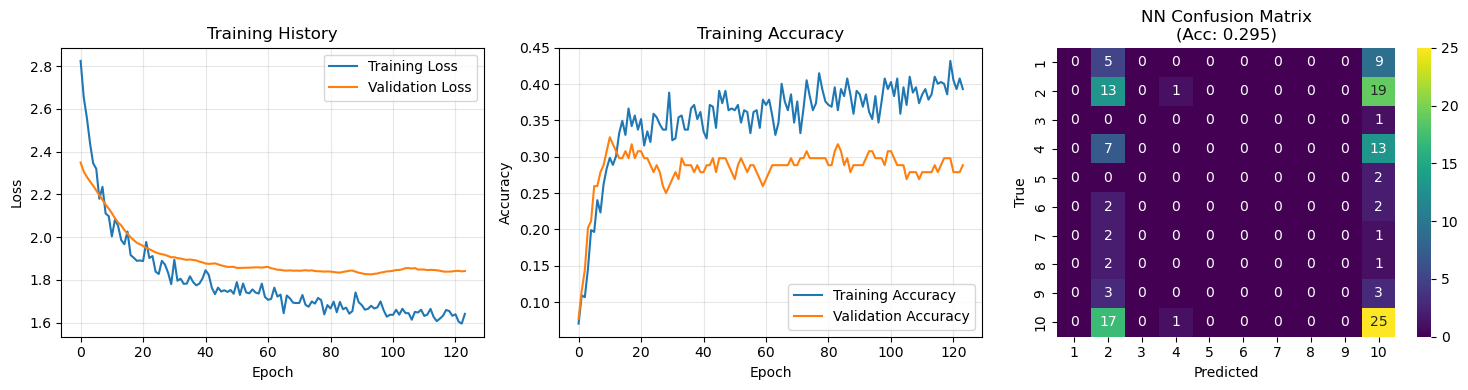

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Prepare data for neural network
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Neural network input: {X.shape[1]} CSD PDF features")
print(f"Classes: {sorted(np.unique(y))}")

num_classes = len(np.unique(y))
y_categorical = keras.utils.to_categorical(y - 1, num_classes)

X_train, X_test, y_train, y_test, y_cat_train, y_cat_test = train_test_split(
    X, y, y_categorical, test_size=test_size, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build smaller neural network for smaller dataset
print("\nBuilding neural network for CSD nuclearity classification...")

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),  # Higher dropout for smaller dataset
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Model architecture:")
model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6)
]

print("\nTraining neural network...")
history = model.fit(
    X_train_scaled, y_cat_train,
    batch_size=min(32, len(X_train_scaled) // 4),  # Smaller batch size
    epochs=200,  # More epochs with early stopping
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1) + 1

accuracy_nn = accuracy_score(y_test, y_pred_classes)
f1_weighted_nn = f1_score(y_test, y_pred_classes, average='weighted', zero_division=0)
f1_macro_nn = f1_score(y_test, y_pred_classes, average='macro', zero_division=0)

print(f"\nNeural Network Results (CSD):")
print(f"Accuracy: {accuracy_nn:.3f}")
print(f"F1-score (weighted): {f1_weighted_nn:.3f}")
print(f"F1-score (macro): {f1_macro_nn:.3f}")


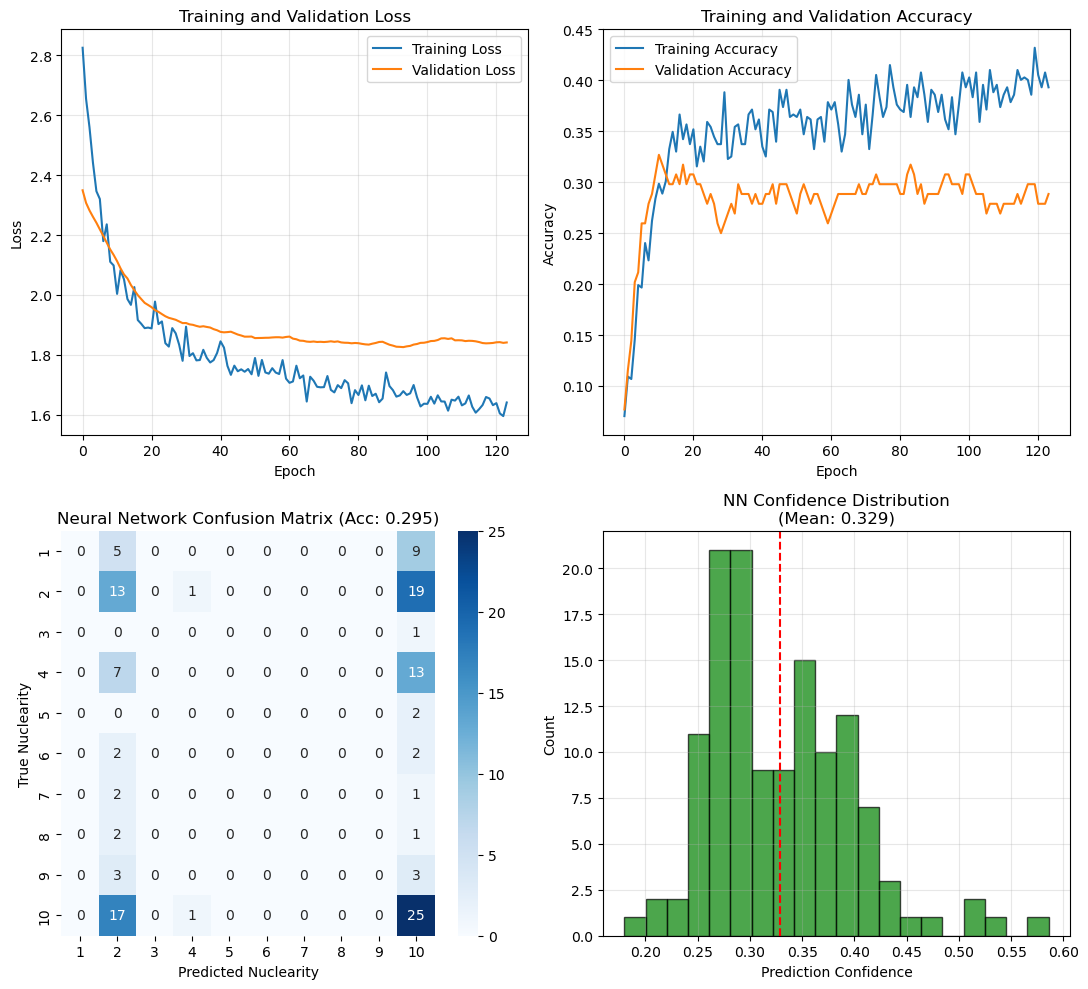

In [14]:
# Visualization: Training history and confusion matrix
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

# Training history - Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
conf_matrix_nn = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[1, 0].set_xlabel('Predicted Nuclearity')
axes[1, 0].set_ylabel('True Nuclearity')
axes[1, 0].set_title(f'Neural Network Confusion Matrix (Acc: {accuracy_nn:.3f})')

# Prediction confidence distribution
confidence_scores = np.max(y_pred_prob, axis=1)
axes[1, 1].hist(confidence_scores, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_xlabel('Prediction Confidence')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'NN Confidence Distribution\n(Mean: {confidence_scores.mean():.3f})')
axes[1, 1].axvline(confidence_scores.mean(), color='red', linestyle='--')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


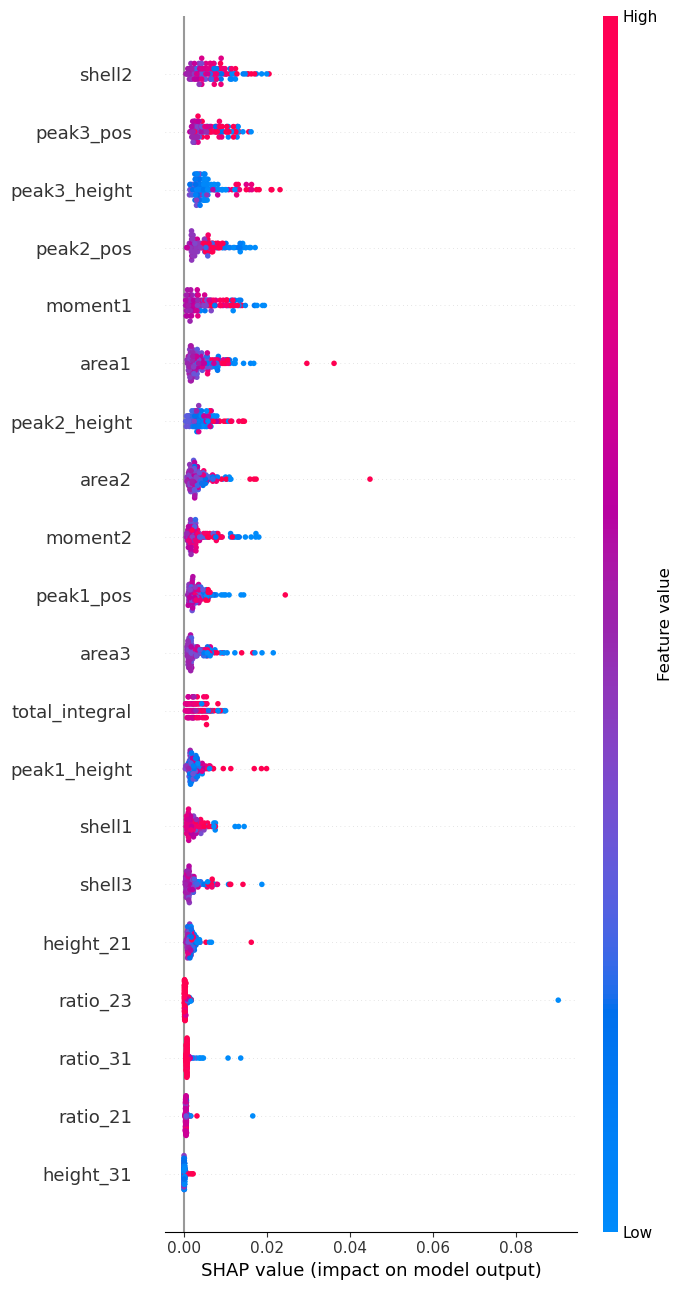

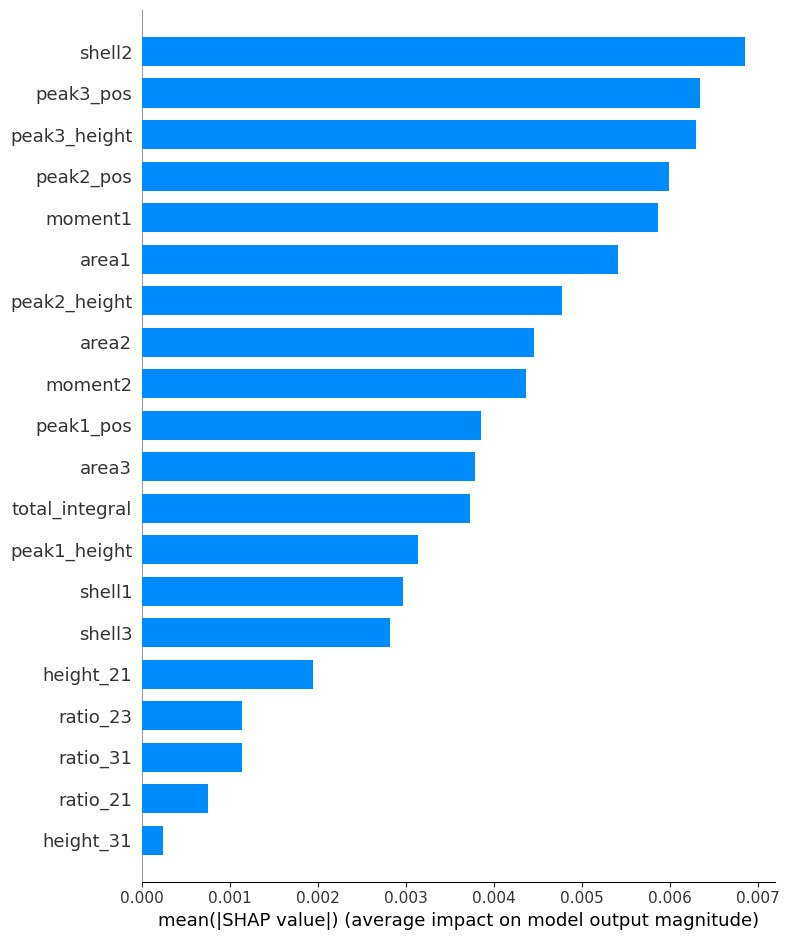

In [15]:
# SHAP explanations for the neural network (sampled for speed)
try:
    import shap
except ImportError as exc:
    raise ImportError("Install shap (pip install shap) before running this cell.") from exc

# Sample a subset for SHAP to keep runtime reasonable
rng = np.random.default_rng(42)
background_size = min(200, X_train_scaled.shape[0])
sample_size = min(300, X_test_scaled.shape[0])

background_idx = rng.choice(X_train_scaled.shape[0], size=background_size, replace=False)
sample_idx = rng.choice(X_test_scaled.shape[0], size=sample_size, replace=False)

background = X_train_scaled[background_idx]
X_shap = X_test_scaled[sample_idx]

# Build SHAP explainer for the trained Keras model
explainer = shap.Explainer(model, background, feature_names=feature_names_clean)
shap_values = explainer(X_shap)

# For multi-class outputs, summarize by mean absolute contribution per feature
if hasattr(shap_values, "values") and shap_values.values.ndim == 3:
    shap_values_mean = shap.Explanation(
        values=np.mean(np.abs(shap_values.values), axis=2),
        base_values=np.mean(shap_values.base_values, axis=1) if shap_values.base_values.ndim == 2 else shap_values.base_values,
        data=shap_values.data,
        feature_names=shap_values.feature_names,
    )
    shap_to_plot = shap_values_mean
else:
    shap_to_plot = shap_values

# Summary plots
shap.summary_plot(shap_to_plot, features=X_shap, feature_names=feature_names_clean, show=True, plot_size=(7,13))
shap.summary_plot(shap_to_plot, features=X_shap, feature_names=feature_names_clean, plot_type="bar", show=True)

## Final Performance Comparison: CSD PDF Features

In [12]:
# ============================================================================
# FINAL ALGORITHM COMPARISON - CSD PDF FEATURES
# ============================================================================
print(f"\n" + "="*70)
print("FINAL ALGORITHM PERFORMANCE COMPARISON (CSD PDF Features)")
print("="*70)
print(f"{'Algorithm':<35} {'Accuracy':<12} {'F1-Weighted':<12}")
print("-"*70)
print(f"{'Neural Network':<35} {accuracy_nn:.3f}        {f1_weighted_nn:.3f}")
print(f"{'Gradient Boosting':<35} {accuracy:.3f}        {f1_weighted:.3f}")
print(f"{'Random Forest':<35} {accuracy_rf:.3f}        {f1_weighted_rf:.3f}")
print(f"{'LogReg + Polynomial':<35} {accuracy_lr_poly:.3f}        {f1_lr_poly:.3f}")
print(f"{'Naive Bayes':<35} {accuracy_nb_improved:.3f}        {f1_nb_improved:.3f}")
print(f"{'Tuned Logistic Regression':<35} {accuracy_lr_improved:.3f}        {f1_lr_improved:.3f}")
print("="*70)

# Identify best performing algorithms
algorithms = ['Gradient Boosting', 'Random Forest', 'Naive Bayes', 
              'Tuned LogReg', 'LogReg+Poly', 'Neural Network']
accuracies = [accuracy, accuracy_rf, accuracy_nb_improved, 
              accuracy_lr_improved, accuracy_lr_poly, accuracy_nn]
f1_scores = [f1_weighted, f1_weighted_rf, f1_nb_improved, 
             f1_lr_improved, f1_lr_poly, f1_weighted_nn]

best_acc_idx = np.argmax(accuracies)
best_f1_idx = np.argmax(f1_scores)

print(f"\nBest Accuracy: {algorithms[best_acc_idx]} ({accuracies[best_acc_idx]:.3f})")
print(f"Best F1-Score: {algorithms[best_f1_idx]} ({f1_scores[best_f1_idx]:.3f})")

print("\n" + "="*70)
print("Analysis complete! Results saved to:", csd_features_dir)


FINAL ALGORITHM PERFORMANCE COMPARISON (CSD PDF Features)
Algorithm                           Accuracy     F1-Weighted 
----------------------------------------------------------------------
Neural Network                      0.295        0.219
Gradient Boosting                   0.225        0.210
Random Forest                       0.302        0.198
LogReg + Polynomial                 0.295        0.203
Naive Bayes                         0.124        0.139
Tuned Logistic Regression           0.287        0.233

Best Accuracy: Random Forest (0.302)
Best F1-Score: Tuned LogReg (0.233)

Analysis complete! Results saved to: /workspace/home/pdf-nn-data/csd_structures/pdf_features
